# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

The data represents multiple direct marketing campaigns conducted by a Portuguese retail bank over a 5 year period from May 2008 to June 2013, involving a total of 52,944 phone contacts. The dataset is unbalanced with only 12.38% of contacts resulting in a successful subscription.

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [3]:
import pandas as pd

In [6]:
df = pd.read_csv('sample_data/bank-additional-full.csv', sep = ';')

In [7]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [8]:
print(df.shape)
print(df['y'].value_counts(normalize=True))

(41188, 21)
y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [45]:
# Check for missing values
print(df.isnull().sum())
print()
# Check data types
print(df.dtypes)

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object


The dataset contains no explicit missing values (isnull().sum() returns 0 for all columns). However, several categorical features encode missing information as "unknown", which may need to be addressed during preprocessing.
Several object type columns will need to be encoded before modeling: job, marital, education, default, housing, loan, contact, month, day_of_week, and poutcome. The target variable y is also an object type ("yes"/"no") and will need to be coerced to binary (1/0) for classification purposes.

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [46]:
# Display dataset info to better understand the features and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

The objective is to predict whether a customer will subscribe to a long-term bank deposit when contacted via a telemarketing phone call. By accurately identifying customers most likely to subscribe, the bank can target the right customers, reduce unnecessary calls, lower campaign costs, and improve the overall success rate of their marketing campaigns.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [47]:
# Select only bank client features
bank_features = ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'y']
df_bank = df[bank_features]

# Encode categorical features using get_dummies
df_encoded = pd.get_dummies(df_bank.drop('y', axis=1))

# Convert target variable to binary (1=yes, 0=no)
y = (df_bank['y'] == 'yes').astype(int)

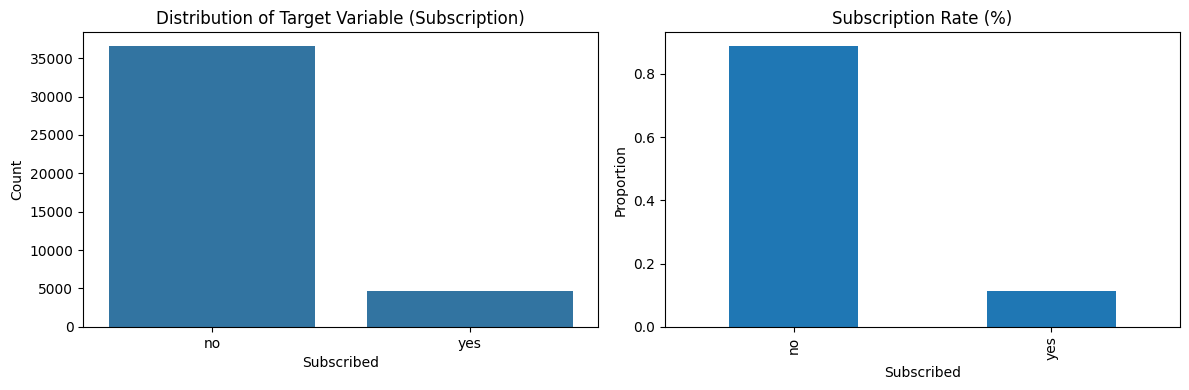

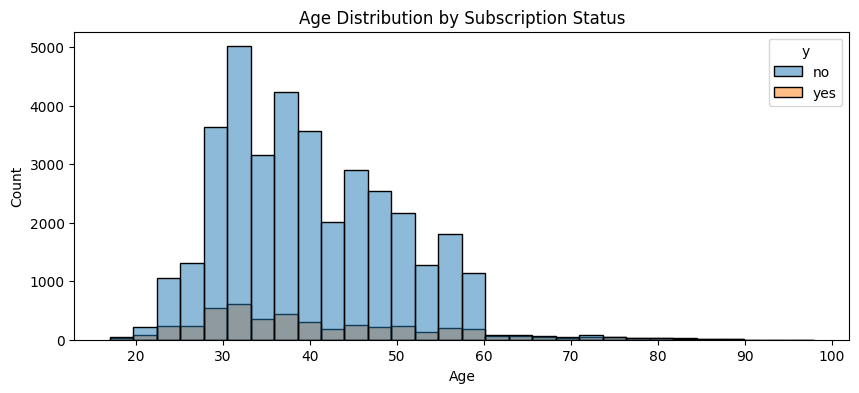

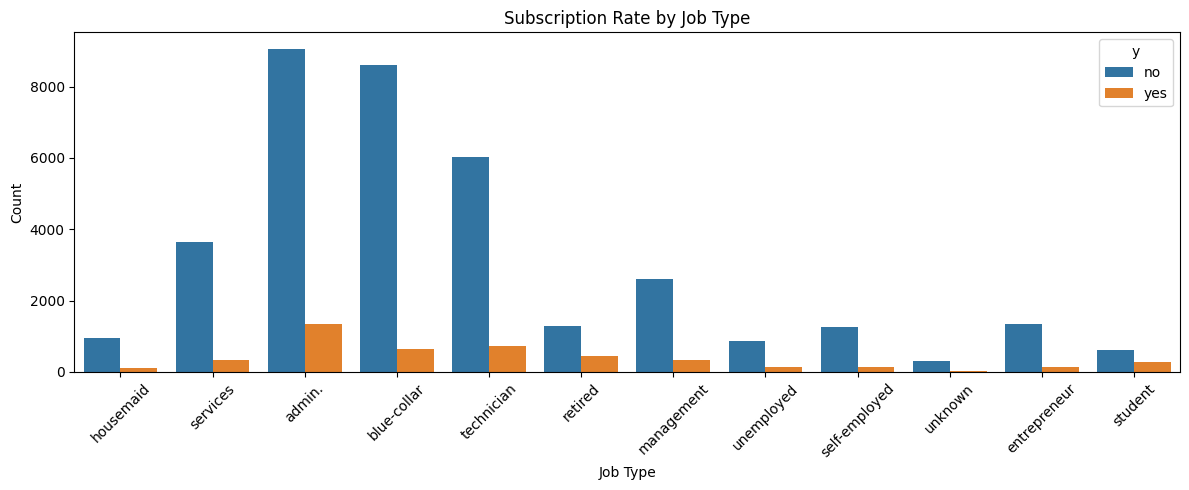

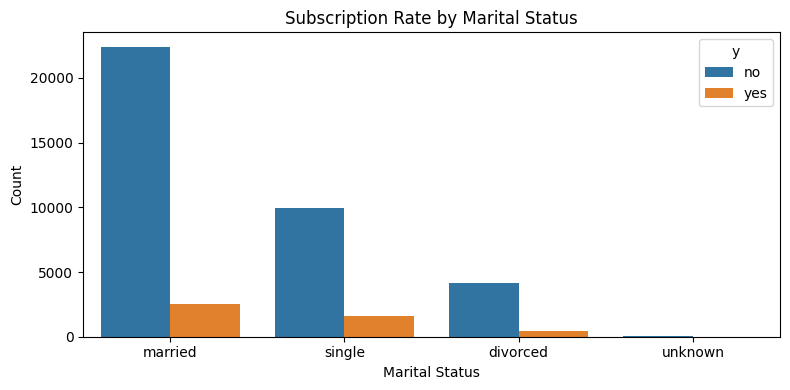

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot 1: Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot of target variable
sns.countplot(x='y', data=df_bank, ax=axes[0])
axes[0].set_title('Distribution of Target Variable (Subscription)')
axes[0].set_xlabel('Subscribed')
axes[0].set_ylabel('Count')

# Percentage plot
df_bank['y'].value_counts(normalize=True).plot(kind='bar', ax=axes[1])
axes[1].set_title('Subscription Rate (%)')
axes[1].set_xlabel('Subscribed')
axes[1].set_ylabel('Proportion')
plt.tight_layout()
plt.show()

# Plot 2: Age distribution
plt.figure(figsize=(10, 4))
sns.histplot(data=df_bank, x='age', hue='y', bins=30)
plt.title('Age Distribution by Subscription Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# Plot 3: Subscription rate by job
plt.figure(figsize=(12, 5))
sns.countplot(data=df_bank, x='job', hue='y')
plt.title('Subscription Rate by Job Type')
plt.xlabel('Job Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot 4: Subscription rate by marital status
plt.figure(figsize=(8, 4))
sns.countplot(data=df_bank, x='marital', hue='y')
plt.title('Subscription Rate by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [49]:
df_encoded.head()

,age,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,...,education_unknown,default_no,default_unknown,default_yes,housing_no,housing_unknown,housing_yes,loan_no,loan_unknown,loan_yes
0,56,False,False,False,True,False,False,False,False,False,...,False,True,False,False,True,False,False,True,False,False
1,57,False,False,False,False,False,False,False,True,False,...,False,False,True,False,True,False,False,True,False,False
2,37,False,False,False,False,False,False,False,True,False,...,False,True,False,False,False,False,True,True,False,False
3,40,True,False,False,False,False,False,False,False,False,...,False,True,False,False,True,False,False,True,False,False
4,56,False,False,False,False,False,False,False,True,False,...,False,True,False,False,True,False,False,False,False,True


In [50]:
# Verify encoding - check shape and target distribution
print(df_encoded.shape)
print(y.value_counts(normalize=True))

(41188, 34)
y
0    0.887346
1    0.112654
Name: proportion, dtype: float64


### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [52]:
from sklearn.model_selection import train_test_split
# Split data into 75% training and 25% test sets
# random_state=42 ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(df_encoded, y, random_state=42)

# Verify split shapes
print(X_train.shape)
print(X_test.shape)

(30891, 34)
(10297, 34)


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [53]:
# Establish baseline using DummyClassifier - predicts majority class every time
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier()
dummy.fit(X_train, y_train)
baseline = dummy.score(X_test, y_test)
print(f"Baseline Score: {baseline:.4f}")

Baseline Score: 0.8880


"The baseline DummyClassifier achieves an accuracy of 88.80% by simply predicting 'no' for every customer. This reflects the class imbalance in the dataset — any meaningful model must significantly outperform this score by correctly identifying actual subscribers."


### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [54]:
# Build a basic Logistic Regression model with default parameters
from sklearn.linear_model import LogisticRegression
import time

start = time.time()
lr = LogisticRegression()
lr.fit(X_train, y_train)
print(f"Logistic Regression: Score={lr.score(X_test, y_test):.4f}, Time={time.time()-start:.4f}s")

Logistic Regression: Score=0.8880, Time=1.9702s


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


A basic Logistic Regression model is built using default parameters as a starting point. The convergence warning indicates the model needs either more iterations or feature scaling to fully optimize.


### Problem 9: Score the Model

What is the accuracy of your model?

The accuracy of the Logistic Regression model is 88.80%, which is virtually identical to the baseline DummyClassifier score of 88.80%. This suggests the model is not learning meaningful patterns and is likely predicting the majority class ('no') for most customers — a direct result of the severe class imbalance in the dataset (88.7% 'no' vs 11.3% 'yes'). Additionally, the convergence warning indicates the model has not fully optimized, suggesting further tuning is needed.

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [55]:
# Compare all four models using default settings
# Tracking train time, train accuracy and test accuracy for each model
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import time

models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC()
}

results = []
for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    train_score = model.score(X_train, y_train)  # Train accuracy
    test_score = model.score(X_test, y_test)      # Test accuracy
    results.append({'Model': name,
                    'Train Time': round(train_time, 4),
                    'Train Accuracy': round(train_score, 4),
                    'Test Accuracy': round(test_score, 4)})

results_df = pd.DataFrame(results)
results_df = results_df.set_index('Model')
print(results_df)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                     Train Time  Train Accuracy  Test Accuracy
Model                                                         
Logistic Regression      1.4395          0.8871         0.8880
Decision Tree            0.2281          0.9170         0.8652
KNN                      0.0168          0.8896         0.8776
SVM                     14.3316          0.8871         0.8880


All four models performed similarly to the baseline DummyClassifier score of 88.80%, indicating that the severe class imbalance (88.7% 'no' vs 11.3% 'yes') is preventing the models from learning meaningful patterns. In terms of training speed, KNN was the fastest (0.02s) since it requires no actual training — it simply memorizes the data and computes distances at prediction time. SVM was by far the slowest (14.33s), making it potentially impractical for large datasets. Notably, Decision Tree shows signs of overfitting — its train accuracy (91.70%) is noticeably higher than its test accuracy (86.52%), suggesting the model memorized the training data rather than learning generalizable patterns. Overall, with only basic bank client features and no handling of class imbalance, none of the models offer meaningful improvement over the baseline.

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [56]:
# Step 1: KNN hyperparameter tuning with recall as metric
# Recall is chosen because missing a potential subscriber is costlier than a wasted call
params = {'n_neighbors': [3, 5, 7, 11, 15]}
grid_knn = GridSearchCV(KNeighborsClassifier(),
                        param_grid=params,
                        scoring='recall')
grid_knn.fit(X_train, y_train)
print(f"Best Parameters: {grid_knn.best_params_}")
print(f"Best Recall Score: {grid_knn.best_score_:.4f}")
print(f"Test Accuracy: {grid_knn.score(X_test, y_test):.4f}")

Best Parameters: {'n_neighbors': 3}
Best Recall Score: 0.1038
Test Accuracy: 0.0963


In [57]:
# Step 2: Decision Tree hyperparameter tuning without class_weight
params = {'max_depth': [3, 5, 7, 10, 15],
          'min_samples_split': [2, 5, 10]}
grid_dt = GridSearchCV(DecisionTreeClassifier(),
                       param_grid=params,
                       scoring='recall')
grid_dt.fit(X_train, y_train)
print(f"Best Parameters: {grid_dt.best_params_}")
print(f"Best Recall Score: {grid_dt.best_score_:.4f}")
print(f"Test Accuracy: {grid_dt.score(X_test, y_test):.4f}")

Best Parameters: {'max_depth': 15, 'min_samples_split': 2}
Best Recall Score: 0.0766
Test Accuracy: 0.0703


In [58]:
# Step 3: Decision Tree with class_weight='balanced' to handle imbalance
params = {'max_depth': [3, 5, 7, 10, 15],
          'min_samples_split': [2, 5, 10]}
grid_dt_balanced = GridSearchCV(DecisionTreeClassifier(class_weight='balanced'),
                                param_grid=params,
                                scoring='recall')
grid_dt_balanced.fit(X_train, y_train)
print(f"Best Parameters: {grid_dt_balanced.best_params_}")
print(f"Best Recall Score: {grid_dt_balanced.best_score_:.4f}")
print(f"Test Accuracy: {grid_dt_balanced.score(X_test, y_test):.4f}")

Best Parameters: {'max_depth': 3, 'min_samples_split': 2}
Best Recall Score: 0.9134
Test Accuracy: 0.9046


In [59]:
# Step 4: Logistic Regression with class_weight='balanced'
params = {'C': [0.001, 0.01, 0.1, 1, 10]}
grid_lr = GridSearchCV(LogisticRegression(class_weight='balanced', max_iter=1000),
                        param_grid=params,
                        scoring='recall')
grid_lr.fit(X_train, y_train)
print(f"Best Parameters: {grid_lr.best_params_}")
print(f"Best Recall Score: {grid_lr.best_score_:.4f}")
print(f"Test Accuracy: {grid_lr.score(X_test, y_test):.4f}")

Best Parameters: {'C': 0.001}
Best Recall Score: 0.6662
Test Accuracy: 0.6565


In [60]:
# Step 5: SVM with class_weight='balanced' on smaller dataset due to computational cost
df_small = pd.read_csv('sample_data/bank-additional.csv', sep=';')
bank_features = ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'y']
df_small_bank = df_small[bank_features]
X_small = pd.get_dummies(df_small_bank.drop('y', axis=1))
y_small = (df_small_bank['y'] == 'yes').astype(int)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_small, y_small, random_state=42)

params = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
grid_svm = GridSearchCV(SVC(class_weight='balanced'),
                        param_grid=params,
                        scoring='recall')
grid_svm.fit(X_train_s, y_train_s)
print(f"Best Parameters: {grid_svm.best_params_}")
print(f"Best Recall Score: {grid_svm.best_score_:.4f}")
print(f"Test Accuracy: {grid_svm.score(X_test_s, y_test_s):.4f}")

Best Parameters: {'C': 0.1, 'kernel': 'linear'}
Best Recall Score: 0.6228
Test Accuracy: 0.5963


To improve model performance on this imbalanced dataset, two strategies were explored: hyperparameter tuning using GridSearchCV and adjusting the performance metric to recall, since the business cost of missing a potential subscriber is higher than making an unnecessary call.
Initial hyperparameter tuning without addressing class imbalance yielded poor results, with recall scores below 10% for both KNN and Decision Tree. Adding class_weight='balanced' dramatically improved performance by penalizing the model more heavily for misclassifying the minority class ("yes").
The Decision Tree with class_weight='balanced' was the best performing model, achieving a recall of 91.34% and accuracy of 90.46% — the only model to outperform the dummy classifier on both metrics. Logistic Regression improved to 66.62% recall but suffered lower accuracy (65.65%). SVM performed worst at 62.28% recall and 59.63% accuracy, even on the smaller dataset.
Overall, class_weight='balanced' proved to be the most impactful improvement, particularly for the Decision Tree model.

# Findings

This analysis compared four classification models — Logistic Regression, Decision Tree, KNN, and SVM — to predict whether a bank customer will subscribe to a term deposit following a telemarketing call.
*   **Key Finding 1: Class Imbalance is the Biggest Challenge.**
The dataset is heavily imbalanced with 88.7% of customers not subscribing. All four models with default settings scored around 88.80% accuracy — identical to simply predicting "no" for every customer. This means default models provide zero business value.
*   **Key Finding 2: Recall is the Right Metric.**
Accuracy is misleading here. Since missing a potential subscriber costs the bank more than making an extra call, recall — the percentage of actual subscribers correctly identified — is the more appropriate metric.
*   **Key Finding 3: Decision Tree with Balanced Class Weights is the Best Model.**
After tuning, the Decision Tree with class_weight='balanced' achieved the best performance with a recall of 91.34% and accuracy of 90.46%, significantly outperforming all other models. Logistic Regression achieved 66.62% recall and 65.65% accuracy, SVM achieved 62.28% recall and 59.63% accuracy, and KNN performed worst at 10.38% recall after tuning.

# Next Steps and Recommendations
# For the Business:
*   Deploy the Decision Tree model to prioritize customers most likely to subscribe before launching calling campaigns
*   Focus calling efforts on customer segments the tree identifies as high probability — reducing unnecessary calls and costs
*   Use the tree's decision rules to understand which customer profiles are most likely to subscribe

# For Further Modeling:
*   Include additional features beyond basic bank client data — campaign features and economic indicators may improve predictions further
*   Explore additional techniques to handle class imbalance such as SMOTE (oversampling minority class)
*   Consider collecting more data on successful subscribers to better balance the dataset
*   Evaluate models using additional metrics such as precision and F1 score for a more complete picture